In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
reports_dir = Path("../reports")

pred_path = reports_dir / "walk_forward_predictions_DK2.csv"

df = pd.read_csv(pred_path)

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())

df.head()

Rows: 5376
Date range: 2025-02-13 06:00:00 → 2025-09-25 05:00:00


,HourUTC,HourDK,SpotPriceEUR,target_24h_ahead,pred_xgboost_24h,fold,pred_current_price_baseline
0,2025-02-13 06:00:00,2025-02-13 07:00:00,190.330002,229.089996,151.74309,1,190.330002
1,2025-02-13 07:00:00,2025-02-13 08:00:00,222.380005,265.649994,166.08397,1,222.380005
2,2025-02-13 08:00:00,2025-02-13 09:00:00,218.059998,215.110001,151.06252,1,218.059998
3,2025-02-13 09:00:00,2025-02-13 10:00:00,201.910004,181.029999,165.09258,1,201.910004
4,2025-02-13 10:00:00,2025-02-13 11:00:00,182.570007,163.009995,184.02840,1,182.570007


In [3]:
current_price_col = "SpotPriceEUR"
future_actual_price_col = "target_24h_ahead"
forecast_price_col = "pred_xgboost_24h"

df = df.dropna(subset=[
    current_price_col,
    future_actual_price_col,
    forecast_price_col
]).reset_index(drop=True)

df[[current_price_col, future_actual_price_col, forecast_price_col]].head()

,SpotPriceEUR,target_24h_ahead,pred_xgboost_24h
0,190.330002,229.089996,151.74309
1,222.380005,265.649994,166.08397
2,218.059998,215.110001,151.06252
3,201.910004,181.029999,165.09258
4,182.570007,163.009995,184.02840


In [4]:
df["expected_spread"] = df[forecast_price_col] - df[current_price_col]
df["realized_spread"] = df[future_actual_price_col] - df[current_price_col]

df[[
    "HourUTC",
    current_price_col,
    forecast_price_col,
    future_actual_price_col,
    "expected_spread",
    "realized_spread"
]].head()

,HourUTC,SpotPriceEUR,pred_xgboost_24h,target_24h_ahead,expected_spread,realized_spread
0,2025-02-13 06:00:00,190.330002,151.74309,229.089996,-38.586912,38.759994
1,2025-02-13 07:00:00,222.380005,166.08397,265.649994,-56.296035,43.269989
2,2025-02-13 08:00:00,218.059998,151.06252,215.110001,-66.997478,-2.949997
3,2025-02-13 09:00:00,201.910004,165.09258,181.029999,-36.817424,-20.880005
4,2025-02-13 10:00:00,182.570007,184.02840,163.009995,1.458393,-19.560012


In [5]:
threshold = 10  # EUR/MWh

df["signal"] = 0

df.loc[df["expected_spread"] > threshold, "signal"] = 1
df.loc[df["expected_spread"] < -threshold, "signal"] = -1

df["signal"].value_counts()

signal
-1    2235
 0    1589
 1    1552
Name: count, dtype: int64

In [6]:
position_size_mwh = 1.0

df["pnl_eur"] = df["signal"] * df["realized_spread"] * position_size_mwh

df[[
    "HourUTC",
    "signal",
    "expected_spread",
    "realized_spread",
    "pnl_eur"
]].head(10)

,HourUTC,signal,expected_spread,realized_spread,pnl_eur
0,2025-02-13 06:00:00,-1,-38.586912,38.759994,-38.759994
1,2025-02-13 07:00:00,-1,-56.296035,43.269989,-43.269989
2,2025-02-13 08:00:00,-1,-66.997478,-2.949997,2.949997
3,2025-02-13 09:00:00,-1,-36.817424,-20.880005,20.880005
4,2025-02-13 10:00:00,0,1.458393,-19.560012,-0.000000
5,2025-02-13 11:00:00,-1,-33.890232,-17.970001,17.970001
6,2025-02-13 12:00:00,0,-8.221133,-10.939987,-0.000000
7,2025-02-13 13:00:00,-1,-38.868708,-0.880005,0.880005
8,2025-02-13 14:00:00,-1,-36.406071,15.080002,-15.080002
9,2025-02-13 15:00:00,-1,-41.284175,29.379990,-29.379990


In [7]:
df["cumulative_pnl_eur"] = df["pnl_eur"].cumsum()

df[["HourUTC", "pnl_eur", "cumulative_pnl_eur"]].tail()

,HourUTC,pnl_eur,cumulative_pnl_eur
5371,2025-09-25 01:00:00,0.000000,94294.100063
5372,2025-09-25 02:00:00,0.000000,94294.100063
5373,2025-09-25 03:00:00,0.000000,94294.100063
5374,2025-09-25 04:00:00,4.599998,94298.700061
5375,2025-09-25 05:00:00,0.019997,94298.720058


In [8]:
total_pnl = df["pnl_eur"].sum()
n_trades = (df["signal"] != 0).sum()
win_rate = (df.loc[df["signal"] != 0, "pnl_eur"] > 0).mean() * 100
avg_pnl_per_trade = df.loc[df["signal"] != 0, "pnl_eur"].mean()

max_drawdown = (
    df["cumulative_pnl_eur"] 
    - df["cumulative_pnl_eur"].cummax()
).min()

backtest_summary = pd.DataFrame([{
    "threshold_eur_mwh": threshold,
    "position_size_mwh": position_size_mwh,
    "total_pnl_eur": round(total_pnl, 2),
    "n_trades": int(n_trades),
    "win_rate_pct": round(win_rate, 2),
    "avg_pnl_per_trade_eur": round(avg_pnl_per_trade, 2),
    "max_drawdown_eur": round(max_drawdown, 2),
}])

backtest_summary

,threshold_eur_mwh,position_size_mwh,total_pnl_eur,n_trades,win_rate_pct,avg_pnl_per_trade_eur,max_drawdown_eur
0,10,1.0,94298.72,3787,74.31,24.9,-793.74


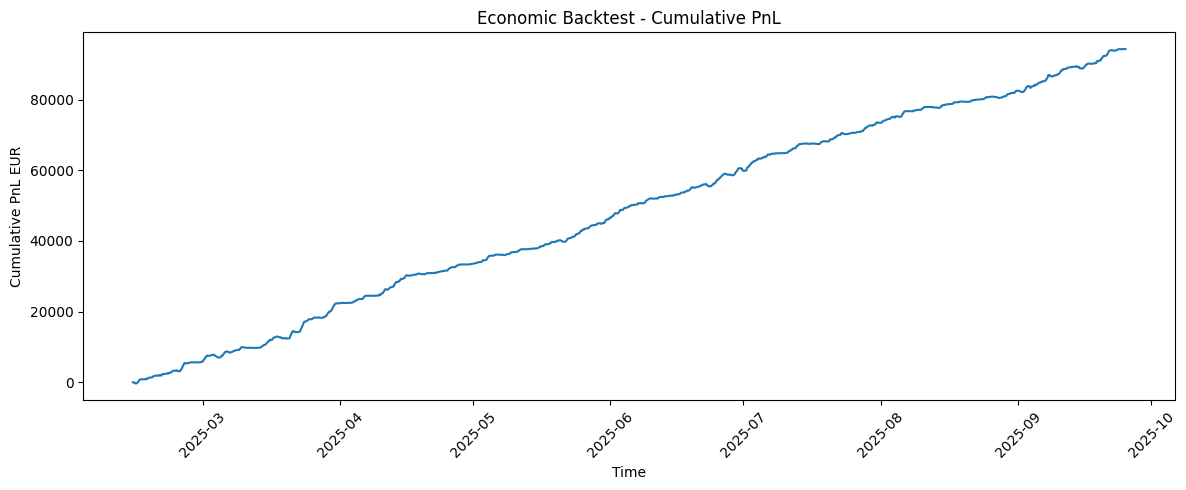

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(df["HourUTC"], df["cumulative_pnl_eur"])

plt.title("Economic Backtest - Cumulative PnL")
plt.xlabel("Time")
plt.ylabel("Cumulative PnL EUR")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
threshold_results = []

thresholds = [0, 5, 10, 15, 20, 25, 30]

for th in thresholds:
    temp = df.copy()
    
    temp["signal"] = 0
    temp.loc[temp["expected_spread"] > th, "signal"] = 1
    temp.loc[temp["expected_spread"] < -th, "signal"] = -1
    
    temp["pnl_eur"] = temp["signal"] * temp["realized_spread"] * position_size_mwh
    temp["cumulative_pnl_eur"] = temp["pnl_eur"].cumsum()
    
    trades = temp[temp["signal"] != 0]
    
    total_pnl = temp["pnl_eur"].sum()
    n_trades = len(trades)
    win_rate = (trades["pnl_eur"] > 0).mean() * 100 if n_trades > 0 else np.nan
    avg_pnl = trades["pnl_eur"].mean() if n_trades > 0 else np.nan
    max_drawdown = (
        temp["cumulative_pnl_eur"] 
        - temp["cumulative_pnl_eur"].cummax()
    ).min()
    
    threshold_results.append({
        "threshold": th,
        "total_pnl_eur": round(total_pnl, 2),
        "n_trades": n_trades,
        "win_rate_pct": round(win_rate, 2) if not np.isnan(win_rate) else np.nan,
        "avg_pnl_per_trade_eur": round(avg_pnl, 2) if not np.isnan(avg_pnl) else np.nan,
        "max_drawdown_eur": round(max_drawdown, 2),
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,threshold,total_pnl_eur,n_trades,win_rate_pct,avg_pnl_per_trade_eur,max_drawdown_eur
0,0,100857.71,5376,68.36,18.76,-934.91
1,5,99485.51,4558,71.48,21.83,-793.74
2,10,94298.72,3787,74.31,24.90,-793.74
3,15,84818.56,3053,75.96,27.78,-793.74
4,20,75420.61,2390,79.00,31.56,-793.74
5,25,64481.73,1804,81.37,35.74,-750.25
6,30,53337.55,1334,83.58,39.98,-728.28


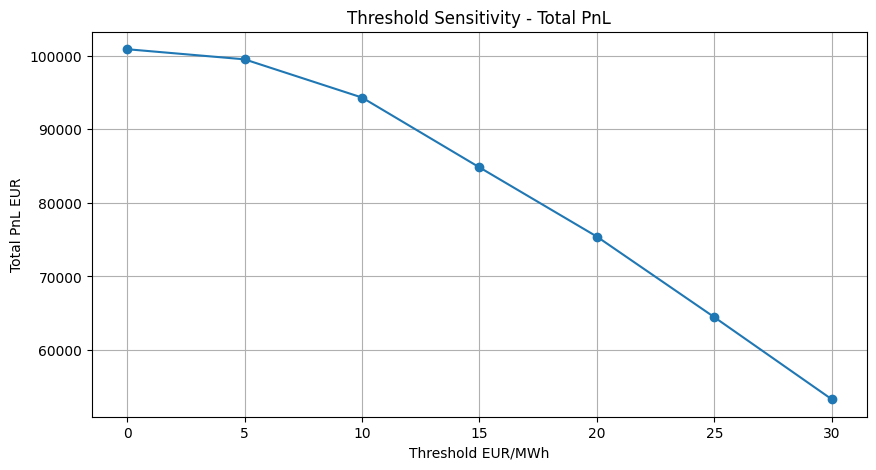

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["total_pnl_eur"],
    marker="o"
)

plt.title("Threshold Sensitivity - Total PnL")
plt.xlabel("Threshold EUR/MWh")
plt.ylabel("Total PnL EUR")
plt.grid(True)
plt.show()

In [12]:
backtest_summary.to_csv(
    reports_dir / "economic_backtest_summary_DK2.csv",
    index=False
)

threshold_results_df.to_csv(
    reports_dir / "economic_backtest_thresholds_DK2.csv",
    index=False
)

df.to_csv(
    reports_dir / "economic_backtest_trades_DK2.csv",
    index=False
)

print("Saved economic backtesting reports.")

Saved economic backtesting reports.
